예제 7.1 위치 인코딩

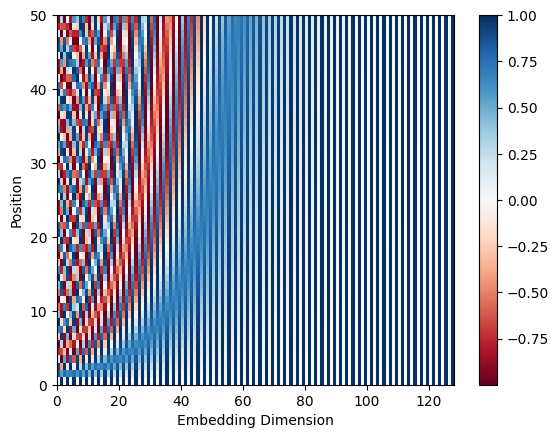

In [ ]:
import math
import torch
from torch import nn
from matplotlib import pyplot as plt

class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len, dropout=0.1):
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)

    position = torch.arange(max_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )

    pe = torch.zeros(max_len, 1, d_model)
    pe[:, 0, 0::2] = torch.sin(position * div_term)
    pe[:, 0, 1::2] = torch.cos(position * div_term)
    self.register_buffer("pe", pe)

  def forward(self, x):
    x = x + self.pe[: x.size(0)]
    return self.dropout(x)

encoding = PositionalEncoding(d_model=128, max_len=50)

plt.pcolormesh(encoding.pe.numpy().squeeze(), cmap="RdBu")
plt.xlabel("Embedding Dimension")
plt.xlim((0, 128))
plt.ylabel("Position")
plt.colorbar()
plt.show()

예제 7.2 데이터셋 다운로드 및 전처리

In [ ]:
pip install datasets

In [ ]:
!pip install datasets spacy
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 107.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 112.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from datasets import load_dataset
import spacy
from collections import Counter

# ── 기본 설정 ──────────────────────────────────────
SRC_LANGUAGE = "de"
TGT_LANGUAGE = "en"
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ["<unk>", "<pad>", "<bos>", "<eos>"]

# ── 토크나이저 ─────────────────────────────────────
spacy_de = spacy.load("de_core_news_sm")
spacy_en = spacy.load("en_core_web_sm")

token_transform = {
    SRC_LANGUAGE: lambda text: [tok.text for tok in spacy_de.tokenizer(text)],
    TGT_LANGUAGE: lambda text: [tok.text for tok in spacy_en.tokenizer(text)],
}

# ── 데이터셋 ───────────────────────────────────────
dataset = load_dataset("bentrevett/multi30k")
train_data = dataset["train"]

# ── Vocab 클래스 (torchtext.vocab 대체) ────────────
class Vocab:
    def __init__(self, counter, specials, min_freq=1):
        self.itos = specials.copy()  # index → token
        for token, freq in counter.items():
            if freq >= min_freq and token not in specials:
                self.itos.append(token)
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}  # token → index
        self.default_index = 0  # <unk>

    def __len__(self):
        return len(self.itos)

    def __getitem__(self, token):
        return self.stoi.get(token, self.default_index)

    def lookup_indices(self, tokens):
        return [self[tok] for tok in tokens]

    def lookup_tokens(self, indices):
        return [self.itos[i] for i in indices]

    def set_default_index(self, idx):
        self.default_index = idx

# ── Vocab 빌드 ─────────────────────────────────────
vocab_transform = {}
for lang in [SRC_LANGUAGE, TGT_LANGUAGE]:
    counter = Counter()
    for item in train_data:
        counter.update(token_transform[lang](item[lang]))
    vocab_transform[lang] = Vocab(counter, special_symbols, min_freq=1)

print("DE vocab size:", len(vocab_transform["de"]))
print("EN vocab size:", len(vocab_transform["en"]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DE vocab size: 19214
EN vocab size: 10837


예제 7.3 트랜스포머 모델 구성

In [ ]:
import math
import torch
from torch import nn


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)


class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size

    def forward(self, tokens):
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)


class Seq2SeqTransformer(nn.Module):
    def __init__(
        self,
        num_encoder_layers,
        num_decoder_layers,
        emb_size,
        max_len,
        nhead,
        src_vocab_size,
        tgt_vocab_size,
        dim_feedforward,
        dropout=0.1,
    ):
        super().__init__()
        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
        self.positional_encoding = PositionalEncoding(
            d_model=emb_size, max_len=max_len, dropout=dropout
        )
        self.transformer = nn.Transformer(
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.generator = nn.Linear(emb_size, tgt_vocab_size)

    def forward(
        self,
        src,
        trg,
        src_mask,
        tgt_mask,
        src_padding_mask,
        tgt_padding_mask,
        memory_key_padding_mask,
    ):
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
        outs = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            memory_mask=None,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )
        return self.generator(outs)

    def encode(self, src, src_mask):
        return self.transformer.encoder(
            self.positional_encoding(self.src_tok_emb(src)), src_mask
        )

    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(
            self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask
        )

예제 7.4 트랜스포머 모델 구조

In [ ]:
from torch import optim


BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = Seq2SeqTransformer(
    num_encoder_layers=3,
    num_decoder_layers=3,
    emb_size=512,
    max_len=512,
    nhead=8,
    src_vocab_size=len(vocab_transform[SRC_LANGUAGE]),
    tgt_vocab_size=len(vocab_transform[TGT_LANGUAGE]),
    dim_feedforward=512,
).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)
optimizer = optim.Adam(model.parameters())

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("│  │  └", sssub_name)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


src_tok_emb
└ embedding
tgt_tok_emb
└ embedding
positional_encoding
└ dropout
transformer
└ encoder
│  └ layers
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  └ norm
└ decoder
│  └ layers
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  └ norm
generator


예제 7.5 배치 데이터 생성

In [ ]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
import torch

def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func

def input_transform(token_ids):
    return torch.cat(
        (torch.tensor([BOS_IDX]), torch.tensor(token_ids), torch.tensor([EOS_IDX]))
    )

def collator(batch):
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        src_batch.append(text_transform[SRC_LANGUAGE](src_sample.rstrip("\n")))
        tgt_batch.append(text_transform[TGT_LANGUAGE](tgt_sample.rstrip("\n")))

    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch

text_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    text_transform[language] = sequential_transforms(
        token_transform[language],
        vocab_transform[language].lookup_indices,  # ← 이것도 수정
        input_transform
    )

# ── Multi30k → datasets로 대체 ──────────────────────
dataset = load_dataset("bentrevett/multi30k")
valid_data = [(item["de"], item["en"]) for item in dataset["validation"]]

dataloader = DataLoader(valid_data, batch_size=BATCH_SIZE, collate_fn=collator)
source_tensor, target_tensor = next(iter(dataloader))

print("(source, target):")
print(valid_data[0])

print("source_batch:", source_tensor.shape)
print(source_tensor)

print("target_batch:", target_tensor.shape)
print(target_tensor)

(source, target):
('Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen', 'A group of men are loading cotton onto a truck')
source_batch: torch.Size([35, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [  70,   23,   23,  ...,   23,    4,   23],
        [ 130,   30,  250,  ...,   30, 4360,   24],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])
target_batch: torch.Size([30, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [  25,   25,   25,  ..., 1244,    4,   25],
        [ 255,   32,  246,  ...,   32, 3035,   26],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])


예제 7.6 어텐션 마스크 생성

In [ ]:
def generate_square_subsequent_mask(s):
    mask = (torch.triu(torch.ones((s, s), device=DEVICE)) == 1).transpose(0, 1)
    mask = (
        mask.float()
        .masked_fill(mask == 0, float("-inf"))
        .masked_fill(mask == 1, float(0.0))
    )
    return mask


def create_mask(src, tgt):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool)

    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0, 1)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask


target_input = target_tensor[:-1, :]
target_out = target_tensor[1:, :]

source_mask, target_mask, source_padding_mask, target_padding_mask = create_mask(
    source_tensor, target_input
)

print("source_mask:", source_mask.shape)
print(source_mask)
print("target_mask:", target_mask.shape)
print(target_mask)
print("source_padding_mask:", source_padding_mask.shape)
print(source_padding_mask)
print("target_padding_mask:", target_padding_mask.shape)
print(target_padding_mask)

source_mask: torch.Size([35, 35])
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]], device='cuda:0')
target_mask: torch.Size([29, 29])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf,

예제 7.7 모델 학습 및 평가

In [ ]:
def run(model, optimizer, criterion, split):
    model.train() if split == "train" else model.eval()

    # ── Multi30k → datasets로 대체 ──────────────────
    split_map = {"train": "train", "valid": "validation"}
    data = load_dataset("bentrevett/multi30k")[split_map[split]]
    data_iter = [(item["de"], item["en"]) for item in data]
    dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)
    # ─────────────────────────────────────────────────

    losses = 0
    for source_batch, target_batch in dataloader:
        source_batch = source_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        target_input = target_batch[:-1, :]
        target_output = target_batch[1:, :]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(
            source_batch, target_input
        )

        logits = model(
            src=source_batch,
            trg=target_input,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )

        optimizer.zero_grad()
        loss = criterion(logits.reshape(-1, logits.shape[-1]), target_output.reshape(-1))
        if split == "train":
            loss.backward()
            optimizer.step()
        losses += loss.item()

    return losses / len(dataloader)


for epoch in range(5):
    train_loss = run(model, optimizer, criterion, "train")
    val_loss = run(model, optimizer, criterion, "valid")
    print(f"Epoch: {epoch+1}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch: 1, Train loss: 4.845, Val loss: 4.107
Epoch: 2, Train loss: 3.846, Val loss: 3.719
Epoch: 3, Train loss: 3.526, Val loss: 3.600
Epoch: 4, Train loss: 3.367, Val loss: 3.586
Epoch: 5, Train loss: 3.238, Val loss: 3.555


예제 7.8 트랜스포머 모델 번역 결과

In [ ]:
def greedy_decode(model, source_tensor, source_mask, max_len, start_symbol):
    source_tensor = source_tensor.to(DEVICE)
    source_mask = source_mask.to(DEVICE)

    memory = model.encode(source_tensor, source_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(DEVICE)
    for i in range(max_len - 1):
        memory = memory.to(DEVICE)
        target_mask = generate_square_subsequent_mask(ys.size(0))
        target_mask = target_mask.type(torch.bool).to(DEVICE)

        out = model.decode(ys, memory, target_mask)
        out = out.transpose(0, 1)
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        ys = torch.cat(
            [ys, torch.ones(1, 1).type_as(source_tensor.data).fill_(next_word)], dim=0
        )
        if next_word == EOS_IDX:
            break
    return ys


def translate(model, source_sentence):
    model.eval()
    source_tensor = text_transform[SRC_LANGUAGE](source_sentence).view(-1, 1)
    num_tokens = source_tensor.shape[0]
    src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)
    tgt_tokens = greedy_decode(
        model, source_tensor, src_mask, max_len=num_tokens + 5, start_symbol=BOS_IDX
    ).flatten()
    output = vocab_transform[TGT_LANGUAGE].lookup_tokens(list(tgt_tokens.cpu().numpy()))[1:-1]
    return " ".join(output)


output_oov = translate(model, "Eine Gruppe von Menschen steht vor einem Iglu .")
output = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude .")
print(output_oov)
print(output)

A group of people are sitting on a bench .
A group of people are sitting on a bench .


예제 7.9 문장 생성을 위한 GPT-2 모델 구조

In [ ]:
from transformers import GPT2LMHeadModel


model = GPT2LMHeadModel.from_pretrained(pretrained_model_name_or_path="gpt2")

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("│  │  └", sssub_name)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

transformer
└ wte
└ wpe
└ drop
└ h
│  └ 0
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 1
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 2
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 3
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 4
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 5
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 6
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 7
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 8
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 9
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 10
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 11
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
└ ln_f
lm_head


예제 7.10 GPT-2를 이용한 문장 생성

In [ ]:
from transformers import pipeline


generator = pipeline(task="text-generation", model="gpt2")
outputs = generator(
    text_inputs="Machine learning is",
    max_length=20,
    num_return_sequences=3,
    pad_token_id=generator.tokenizer.eos_token_id
)
print(outputs)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_length', 'pad_token_id', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Machine learning is a good way to get information about your business. But there are so many different kinds of learning tools out there.\n\nHere are a few of the best:\n\nLearning and learning from sources\n\nLearning from sources is great because it helps you see the business from your point of view. It helps you see what\'s going on in your business and it does that when you interact with it. When you\'re using learning methods like that, there\'s always an opportunity to learn something new from your own sources.\n\nBut don\'t always use learning methods like that. Learn from sources in a real work environment and you won\'t get very far.\n\nThe best learning methods are based on a "what\'s going on" approach. You learn from your own sources and you know what\'s going on and you\'re well-prepared for the material you\'re learning from.\n\nLearning from sources is not a learning tool that you can do every day. You learn from your own learning tools and you can l

예제 7.11 CoLA 데이터셋 불러오기

In [1]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader


def collator(batch, tokenizer, device):
    source, labels, texts = zip(*batch)
    tokenized = tokenizer(
        list(texts),
        padding="longest",
        truncation=True,
        return_tensors="pt"
    )
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)
    labels = torch.tensor(labels, dtype=torch.long).to(device)
    return input_ids, attention_mask, labels


# ── CoLA → datasets로 대체 ──────────────────────────
cola = load_dataset("nyu-mll/glue", "cola")

def to_tuple(item):
    return (None, item["label"], item["sentence"])

train_data = [to_tuple(item) for item in cola["train"]]
valid_data = [to_tuple(item) for item in cola["validation"]]
test_data  = [to_tuple(item) for item in cola["test"]]
# ────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

epochs = 3
batch_size = 16
device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    collate_fn=lambda x: collator(x, tokenizer, device),
    shuffle=True,
)
valid_dataloader = DataLoader(
    valid_data, batch_size=batch_size, collate_fn=lambda x: collator(x, tokenizer, device)
)
test_dataloader = DataLoader(
    test_data, batch_size=batch_size, collate_fn=lambda x: collator(x, tokenizer, device)
)

print("Train Dataset Length :", len(train_data))
print("Valid Dataset Length :", len(valid_data))
print("Test Dataset Length :", len(test_data))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train Dataset Length : 8551
Valid Dataset Length : 1043
Test Dataset Length : 1063


예제 7.12 GPT-2 모델 설정

In [2]:
!pip uninstall torchvision -y
!pip install torchvision --pre --index-url https://download.pytorch.org/whl/nightly/cu128

Found existing installation: torchvision 0.27.0.dev20260407+cu128
Uninstalling torchvision-0.27.0.dev20260407+cu128:
  Successfully uninstalled torchvision-0.27.0.dev20260407+cu128
Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
  Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torchvision-0.27.0.dev20260407%2Bcu128-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torchvision-0.27.0.dev20260407%2Bcu128-cp312-cp312-manylinux_2_28_x86_64.whl (8.2 MB)


In [3]:
import torch
from torch import optim
from transformers import GPT2ForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"

model = GPT2ForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="gpt2",
    num_labels=2
).to(device)
model.config.pad_token_id = model.config.eos_token_id
optimizer = optim.Adam(model.parameters(), lr=5e-5)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key                  | Status     | 
---------------------+------------+-
h.{0...11}.attn.bias | UNEXPECTED | 
score.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


예제 7.13 GPT-2 모델 학습 및 검증

In [4]:
import os
os.makedirs("../models", exist_ok=True)

In [5]:
import numpy as np
from torch import nn


def calc_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def train(model, optimizer, dataloader):
    model.train()
    train_loss = 0.0

    for input_ids, attention_mask, labels in dataloader:
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss = train_loss / len(dataloader)
    return train_loss

def evaluation(model, dataloader):
    with torch.no_grad():
        model.eval()
        val_loss, val_accuracy = 0.0, 0.0

        for input_ids, attention_mask, labels in dataloader:
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            logits = outputs.logits
            loss = outputs.loss

            logits = logits.detach().cpu().numpy()
            label_ids = labels.to("cpu").numpy()
            accuracy = calc_accuracy(logits, label_ids)

            val_loss += loss.item()
            val_accuracy += accuracy

    val_loss = val_loss/len(dataloader)
    val_accuracy = val_accuracy/len(dataloader)
    return val_loss, val_accuracy


best_loss = 10000
for epoch in range(epochs):
    train_loss = train(model, optimizer, train_dataloader)
    val_loss, val_accuracy = evaluation(model, valid_dataloader)
    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Val Accuracy {val_accuracy:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "../models/GPT2ForSequenceClassification.pt")
        print("Saved the model weights")

Epoch 1: Train Loss: 0.6673 Val Loss: 0.6224 Val Accuracy 0.6910
Saved the model weights
Epoch 2: Train Loss: 0.5941 Val Loss: 0.5812 Val Accuracy 0.6875
Saved the model weights
Epoch 3: Train Loss: 0.5344 Val Loss: 0.5651 Val Accuracy 0.7115
Saved the model weights


예제 7.14 모델 평가

In [6]:
def evaluation_test(model, dataloader):
    with torch.no_grad():
        model.eval()
        all_preds = []

        for input_ids, attention_mask, labels in dataloader:
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                # labels 안 넘김 ← 핵심
            )
            logits = outputs.logits.detach().cpu().numpy()
            preds = np.argmax(logits, axis=1).flatten()
            all_preds.extend(preds)

    return all_preds


test_preds = evaluation_test(model, test_dataloader)
print(f"Test Predictions: {test_preds[:20]}")
print(f"Total: {len(test_preds)}")

Test Predictions: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0)]
Total: 1063


예제 7.15 네이버 영화 리뷰 데이터 불러오기

In [1]:
!pip install Korpora

In [2]:
import numpy as np
import pandas as pd
from Korpora import Korpora


corpus = Korpora.load("nsmc")
df = pd.DataFrame(corpus.test).sample(20000, random_state=42)

train, valid, test = np.split(
    df.sample(frac=1, random_state=42), [int(0.6 * len(df)), int(0.8 * len(df))]
)

print(train.head(5).to_markdown())
print(f"Training Data Size : {len(train)}")
print(f"Validation Data Size : {len(valid)}")
print(f"Testing Data Size : {len(test)}")


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : e9t@github
    Repository : https://github.com/e9t/nsmc
    References : www.lucypark.kr/docs/2015-pyconkr/#39

    Naver sentiment movie corpus v1.0
    This is a movie review dataset in the Korean language.
    Reviews were scraped from Naver Movies.

    The dataset construction is based on the method noted in
    [Large movie review dataset][^1] from Maas et al., 2011.

    [^1]: http://ai.stanford.edu/~amaas/data/sentiment/

    # License
    CC0 1.0 Universal (CC0 1.0) Public Domain Dedication
    Details in https://creativecommons.org/publicdomain/zero/1.0/

[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ratings_train.txt
[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ra

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


예제 7.16 BERT 입력 텐서 생성

In [3]:
import torch
from transformers import BertTokenizer
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler


def make_dataset(data, tokenizer, device):
    tokenized = tokenizer(
        text=data.text.tolist(),
        padding="longest",
        truncation=True,
        return_tensors="pt"
    )
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)
    labels = torch.tensor(data.label.values, dtype=torch.long).to(device)
    return TensorDataset(input_ids, attention_mask, labels)


def get_datalodader(dataset, sampler, batch_size):
    data_sampler = sampler(dataset)
    dataloader = DataLoader(dataset, sampler=data_sampler, batch_size=batch_size)
    return dataloader


epochs = 5
batch_size = 32
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = BertTokenizer.from_pretrained(
    pretrained_model_name_or_path="bert-base-multilingual-cased",
    do_lower_case=False
)

train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_datalodader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_datalodader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_datalodader(test_dataset, SequentialSampler, batch_size)

print(train_dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

(tensor([   101,  58466,   9812, 118956, 119122,  59095,  10892,   9434, 118888,
           117,   9992,  40032,  30005,    117,   9612,  37824,   9410,  12030,
         42337,  10739,  83491,  12508,    106,    106,    102,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,

예제 7.17 BERT 모델 선언

In [4]:
from torch import optim
from transformers import BertForSequenceClassification


model = BertForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="bert-base-multilingual-cased",
    num_labels=2
).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, eps=1e-8)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [5]:
pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 8.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.4.0
    Uninstalling fsspec-2026.4.0:
      Successfully uninstalled fsspec-2026.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.12.0.dev20260407+cu128 which is incompatible.


예제 7.18 뉴스 요약 데이터셋 불러오기

In [7]:
import numpy as np
from datasets import load_dataset


news = load_dataset("argilla/news-summary", split="test")
df = news.to_pandas().sample(5000, random_state=42)[["text", "prediction"]]
df["prediction"] = df["prediction"].map(lambda x: x[0]["text"])
train, valid, test = np.split(
    df.sample(frac=1, random_state=42), [int(0.6 * len(df)), int(0.8 * len(df))]
)

print(f"Source News : {train.text.iloc[0][:200]}")
print(f"Summarization : {train.prediction.iloc[0][:50]}")
print(f"Training Data Size : {len(train)}")
print(f"Validation Data Size : {len(valid)}")
print(f"Testing Data Size : {len(test)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-ebc48879f34571(…):   0%|          | 0.00/1.54M [00:00<?, ?B/s]

data/test-00000-of-00001-6227bd8eb10a9b5(…):   0%|          | 0.00/31.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20417 [00:00<?, ? examples/s]

Source News : DANANG, Vietnam (Reuters) - Russian President Vladimir Putin said on Saturday he had a normal dialogue with U.S. leader Donald Trump at a summit in Vietnam, and described Trump as civil, well-educated
Summarization : Putin says had useful interaction with Trump at Vi
Training Data Size : 3000
Validation Data Size : 1000
Testing Data Size : 1000


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


예제 7.19 BART 입력 텐서 생성

In [8]:
import torch
from transformers import BartTokenizer
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler
from torch.nn.utils.rnn import pad_sequence


def make_dataset(data, tokenizer, device):
    tokenized = tokenizer(
        text=data.text.tolist(),
        padding="longest",
        truncation=True,
        return_tensors="pt",
        max_length=1024
    )
    labels = []
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)
    for target in data.prediction:
        labels.append(tokenizer.encode(target, return_tensors="pt").squeeze())
    labels = pad_sequence(labels, batch_first=True, padding_value=-100).to(device)
    return TensorDataset(input_ids, attention_mask, labels)



def get_datalodader(dataset, sampler, batch_size):
    data_sampler = sampler(dataset)
    dataloader = DataLoader(dataset, sampler=data_sampler, batch_size=batch_size)
    return dataloader


epochs = 5
batch_size = 8
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = BartTokenizer.from_pretrained(
    pretrained_model_name_or_path="facebook/bart-base"
)

train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_datalodader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_datalodader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_datalodader(test_dataset, SequentialSampler, batch_size)

print(train_dataset[0])

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

(tensor([   0,  495, 1889,  ...,    1,    1,    1], device='cuda:0'), tensor([1, 1, 1,  ..., 0, 0, 0], device='cuda:0'), tensor([    0, 35891,   161,    56,  5616, 10405,    19,   140,    23,  5490,
         3564,     2,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0'))


예제 7.20 BART 모델선언

In [9]:
from torch import optim
from transformers import BartForConditionalGeneration


model = BartForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path="facebook/bart-base"
).to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-5, eps=1e-8)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

In [10]:
pip install evaluate rouge_score absl-py

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24986 sha256=654f488748428a0bad8a59ed964efce1cc0f6214d5077d4fc34d23d6e2ee8eee
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


예제 7.21 BART 모델 학습 및 평가

In [11]:
import numpy as np
import evaluate


def calc_rouge(preds, labels):
    preds = preds.argmax(axis=-1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    rouge2 = rouge_score.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )
    return rouge2["rouge2"]

def train(model, optimizer, dataloader):
    model.train()
    train_loss = 0.0

    for input_ids, attention_mask, labels in dataloader:
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss = train_loss / len(dataloader)
    return train_loss

def evaluation(model, dataloader):
    with torch.no_grad():
        model.eval()
        val_loss, val_rouge = 0.0, 0.0

        for input_ids, attention_mask, labels in dataloader:
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            logits = outputs.logits
            loss = outputs.loss

            logits = logits.detach().cpu().numpy()
            label_ids = labels.to("cpu").numpy()
            rouge = calc_rouge(logits, label_ids)

            val_loss += loss.item()
            val_rouge += rouge

    val_loss = val_loss / len(dataloader)
    val_rouge = val_rouge / len(dataloader)
    return val_loss, val_rouge

rouge_score = evaluate.load("rouge", tokenizer=tokenizer)
best_loss = 10000
for epoch in range(epochs):
    train_loss = train(model, optimizer, train_dataloader)
    val_loss, val_accuracy = evaluation(model, valid_dataloader)
    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Val Rouge {val_accuracy:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "../models/BartForConditionalGeneration.pt")
        print("Saved the model weights")

Epoch 1: Train Loss: 2.1932 Val Loss: 1.8763 Val Rouge 0.2359
Saved the model weights
Epoch 2: Train Loss: 1.6207 Val Loss: 1.8891 Val Rouge 0.2520
Epoch 3: Train Loss: 1.2527 Val Loss: 1.9453 Val Rouge 0.2268
Epoch 4: Train Loss: 0.9685 Val Loss: 2.0856 Val Rouge 0.2469
Epoch 5: Train Loss: 0.7413 Val Loss: 2.2326 Val Rouge 0.2322


예제 7.22 BART 모델 평가

In [12]:
model = BartForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path="facebook/bart-base"
).to(device)
model.load_state_dict(torch.load("../models/BartForConditionalGeneration.pt"))

test_loss, test_rouge_score = evaluation(model, test_dataloader)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test ROUGE-2 Score : {test_rouge_score:.4f}")

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Test Loss : 1.8355
Test ROUGE-2 Score : 0.2445


예제 7.23 문장 요약문 비교

In [19]:
model.eval()

for index in range(5):
    news_text = test.text.iloc[index]
    summarization = test.prediction.iloc[index]

    inputs = tokenizer(
        news_text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=54,
            min_length=10,
            do_sample=False
        )

    predicted_summarization = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    print(f"정답 요약문 : {summarization}")
    print(f"모델 요약문 : {predicted_summarization}\n")

정답 요약문 : Clinton leads Trump by 4 points in Washington Post: ABC News poll
모델 요약문 : Clinton leads Trump by 4 points: Washington Post-ABC News poll

정답 요약문 : Democrats question independence of Trump Supreme Court nominee
모델 요약문 : U.S. senators question Gorsuch's independence

정답 요약문 : In push for Yemen aid, U.S. warned Saudis of threats in Congress
모델 요약문 : U.S. warns Saudi Arabia over humanitarian situation in Yemen

정답 요약문 : Romanian ruling party leader investigated over 'criminal group'
모델 요약문 : Romanian prosecutors charge party leader with 'criminal group'

정답 요약문 : Billionaire environmental activist Tom Steyer endorses Clinton
모델 요약문 : Environmental activist Steyer backs Clinton for U.S. president



예제 7.24 네이버 영화 리뷰 데이터셋 전처리

In [21]:
import numpy as np
import pandas as pd
from Korpora import Korpora


corpus = Korpora.load("nsmc")
df = pd.DataFrame(corpus.test).sample(20000, random_state=42)
train, valid, test = np.split(
    df.sample(frac=1, random_state=42), [int(0.6 * len(df)), int(0.8 * len(df))]
)

print(train.head(5).to_markdown())
print(f"Training Data Size : {len(train)}")
print(f"Validation Data Size : {len(valid)}")
print(f"Testing Data Size : {len(test)}")


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : e9t@github
    Repository : https://github.com/e9t/nsmc
    References : www.lucypark.kr/docs/2015-pyconkr/#39

    Naver sentiment movie corpus v1.0
    This is a movie review dataset in the Korean language.
    Reviews were scraped from Naver Movies.

    The dataset construction is based on the method noted in
    [Large movie review dataset][^1] from Maas et al., 2011.

    [^1]: http://ai.stanford.edu/~amaas/data/sentiment/

    # License
    CC0 1.0 Universal (CC0 1.0) Public Domain Dedication
    Details in https://creativecommons.org/publicdomain/zero/1.0/

[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ratings_train.txt
[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ra

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [22]:
import torch
from transformers import ElectraTokenizer
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler


def make_dataset(data, tokenizer, device):
    tokenized = tokenizer(
        text=data.text.tolist(),
        padding="longest",
        truncation=True,
        return_tensors="pt"
    )
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)
    labels = torch.tensor(data.label.values, dtype=torch.long).to(device)
    return TensorDataset(input_ids, attention_mask, labels)


def get_datalodader(dataset, sampler, batch_size):
    data_sampler = sampler(dataset)
    dataloader = DataLoader(dataset, sampler=data_sampler, batch_size=batch_size)
    return dataloader


epochs = 5
batch_size = 32
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = ElectraTokenizer.from_pretrained(
    pretrained_model_name_or_path="monologg/koelectra-base-v3-discriminator",
    do_lower_case=False,
)

train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_datalodader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_datalodader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_datalodader(test_dataset, SequentialSampler, batch_size)

print(train_dataset[0])

(tensor([    2,  6511, 14347,  4087,  4665,  4112,  2924,  4806,    16,  3809,
         4309,  4275,    16,  3201,  4376,  2891,  4139,  4212,  4007,  6557,
         4200,     5,     5,     3,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0], device='cuda:0'), tensor([1, 1, 1, 1, 1, 1, 1, 

예제 7.25 KoELECTRA 모델 선언

In [23]:
from torch import optim
from transformers import ElectraForSequenceClassification


model = ElectraForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="monologg/koelectra-base-v3-discriminator",
    num_labels=2
).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, eps=1e-8)

config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/452M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-base-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

예제 7.26 뉴스 요약 데이터셋 불러오기

In [24]:
import numpy as np
from datasets import load_dataset


news = load_dataset("argilla/news-summary", split="test")
df = news.to_pandas().sample(5000, random_state=42)[["text", "prediction"]]
df["text"] = "summarize: " + df["text"]
df["prediction"] = df["prediction"].map(lambda x: x[0]["text"])
train, valid, test = np.split(
    df.sample(frac=1, random_state=42), [int(0.6 * len(df)), int(0.8 * len(df))]
)

print(f"Source News : {train.text.iloc[0][:200]}")
print(f"Summarization : {train.prediction.iloc[0][:50]}")
print(f"Training Data Size : {len(train)}")
print(f"Validation Data Size : {len(valid)}")
print(f"Testing Data Size : {len(test)}")

Source News : summarize: DANANG, Vietnam (Reuters) - Russian President Vladimir Putin said on Saturday he had a normal dialogue with U.S. leader Donald Trump at a summit in Vietnam, and described Trump as civil, we
Summarization : Putin says had useful interaction with Trump at Vi
Training Data Size : 3000
Validation Data Size : 1000
Testing Data Size : 1000


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


예제 7.27 뉴스 요약 데이터셋 전처리

In [25]:
import torch
from transformers import T5Tokenizer
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler
from torch.nn.utils.rnn import pad_sequence


def make_dataset(data, tokenizer, device):
    source = tokenizer(
        text=data.text.tolist(),
        padding="max_length",
        max_length=128,
        pad_to_max_length=True,
        truncation=True,
        return_tensors="pt"
    )

    target = tokenizer(
        text=data.prediction.tolist(),
        padding="max_length",
        max_length=128,
        pad_to_max_length=True,
        truncation=True,
        return_tensors="pt"
    )

    source_ids = source["input_ids"].squeeze().to(device)
    source_mask = source["attention_mask"].squeeze().to(device)
    target_ids = target["input_ids"].squeeze().to(device)
    target_mask = target["attention_mask"].squeeze().to(device)
    return TensorDataset(source_ids, source_mask, target_ids, target_mask)

def get_datalodader(dataset, sampler, batch_size):
    data_sampler = sampler(dataset)
    dataloader = DataLoader(dataset, sampler=data_sampler, batch_size=batch_size)
    return dataloader


epochs = 5
batch_size = 8
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = T5Tokenizer.from_pretrained(
    pretrained_model_name_or_path="t5-small"
)

train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_datalodader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_datalodader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_datalodader(test_dataset, SequentialSampler, batch_size)

print(next(iter(train_dataloader)))
print(tokenizer.convert_ids_to_tokens(21603))
print(tokenizer.convert_ids_to_tokens(10))

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[tensor([[21603,    10,    41,  ...,     0,     0,     0],
        [21603,    10,    41,  ...,  1104, 11893,     1],
        [21603,    10,     3,  ..., 11106,   681,     1],
        ...,
        [21603,    10,   549,  ...,   133,    43,     1],
        [21603,    10,   549,  ...,   868,  5869,     1],
        [21603,    10,   549,  ...,    12,   617,     1]], device='cuda:0'), tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), tensor([[    3,   476,  4902,  ...,     0,     0,     0],
        [11543,  2689,    10,  ...,     0,     0,     0],
        [ 2523,   845,    73,  ...,     0,     0,     0],
        ...,
        [ 2759,  2523,  1082,  ...,     0,     0,     0],
        [  412,     5,   134,  ...,     0,     0,     0],
        [ 2523,   870,     7,  ...,     0,     0,     0]], device='cuda:0'), ten

예제 7.28 T5 모델 선언

In [26]:
from torch import optim
from transformers import T5ForConditionalGeneration


model = T5ForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path="t5-small",
).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, eps=1e-8)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

예제 7.29 T5 모델 학습 및 평가

In [27]:
import numpy as np
from torch import nn


def calc_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)


def train(model, optimizer, dataloader):
    model.train()
    train_loss = 0.0

    for source_ids, source_mask, target_ids, target_mask in dataloader:
        decoder_input_ids = target_ids[:, :-1].contiguous()
        labels = target_ids[:, 1:].clone().detach()
        labels[target_ids[:, 1:] == tokenizer.pad_token_id] = -100

        outputs = model(
            input_ids=source_ids,
            attention_mask=source_mask,
            decoder_input_ids=decoder_input_ids,
            labels=labels,
        )

        loss = outputs.loss
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss = train_loss / len(dataloader)
    return train_loss


def evaluation(model, dataloader):
    with torch.no_grad():
        model.eval()
        val_loss = 0.0

        for source_ids, source_mask, target_ids, target_mask in dataloader:
            decoder_input_ids = target_ids[:, :-1].contiguous()
            labels = target_ids[:, 1:].clone().detach()
            labels[target_ids[:, 1:] == tokenizer.pad_token_id] = -100

            outputs = model(
                input_ids=source_ids,
                attention_mask=source_mask,
                decoder_input_ids=decoder_input_ids,
                labels=labels,
            )

            loss = outputs.loss
            val_loss += loss.item()

    val_loss = val_loss / len(dataloader)
    return val_loss


best_loss = 10000
for epoch in range(epochs):
    train_loss = train(model, optimizer, train_dataloader)
    val_loss = evaluation(model, valid_dataloader)
    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "../models/T5ForConditionalGeneration.pt")
        print("Saved the model weights")

Epoch 1: Train Loss: 4.3146 Val Loss: 3.3345
Saved the model weights
Epoch 2: Train Loss: 3.4353 Val Loss: 2.9203
Saved the model weights
Epoch 3: Train Loss: 3.1559 Val Loss: 2.7686
Saved the model weights
Epoch 4: Train Loss: 2.9810 Val Loss: 2.6788
Saved the model weights
Epoch 5: Train Loss: 2.8951 Val Loss: 2.6126
Saved the model weights


예제 7.30 T5 생성 모델 테스트

In [28]:
model.eval()
with torch.no_grad():
    for source_ids, source_mask, target_ids, target_mask in test_dataloader:
        generated_ids = model.generate(
            input_ids=source_ids,
            attention_mask=source_mask,
            max_length=128,
            num_beams=3,
            repetition_penalty=2.5,
            length_penalty=1.0,
            early_stopping=True,
        )

        for generated, target in zip(generated_ids, target_ids):
            pred = tokenizer.decode(
                generated, skip_special_tokens=True, clean_up_tokenization_spaces=True
            )
            actual = tokenizer.decode(
                target, skip_special_tokens=True, clean_up_tokenization_spaces=True
            )
            print("Generated Headline Text:", pred)
            print("Actual Headline Text   :", actual)
        break

Generated Headline Text: Clinton leads Trump by 4 percentage points in four-war race for Nov. 8 election
Actual Headline Text   : Clinton leads Trump by 4 points in Washington Post: ABC News poll
Generated Headline Text: U.S. senators sharpen potential line of attack against Gorsuch's nomination to Supreme Court
Actual Headline Text   : Democrats question independence of Trump Supreme Court nominee
Generated Headline Text: U.S. warns Saudi Arabia over humanitarian situation in Yemen could constrain U.S. aid, a U.S. official says
Actual Headline Text   : In push for Yemen aid, U.S. warned Saudis of threats in Congress
Generated Headline Text: Romanian anti-corruption prosecutors open investigation into Liviu Dragnea on suspicion of forming criminal group to siphon off cash from state projects
Actual Headline Text   : Romanian ruling party leader investigated over 'criminal group'
Generated Headline Text: environmental activist endorsed Hillary Clinton for U.S. president
Actual Headline 